# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [2]:
# Install required libraries (uncomment if needed)
!pip install gensim transformers torch sentence-transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 15.3 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [5]:
import pandas as pd

# Load the dataset
df = pd.read_json("hf://datasets/SetFit/20_newsgroups/train.jsonl", lines=True)


# TODO: Use the SAME 3 categories you chose in Part 1!
my_categories = ["sci.space", "rec.sport.baseball", "talk.politics.guns"]

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

Selected categories: ['sci.space', 'rec.sport.baseball', 'talk.politics.guns']
Filtered dataset size: 1736


In [8]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [9]:
# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['article', 'cowcbnpworldstdcom', 'tombakerworldstdcom', 'tom', 'baker', 'understanding', 'expected', 'error', 'basically', 'known', 'bug', 'warning', 'system', 'software', 'thing', 'checked', 'dont', 'right', 'value', 'yet']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [10]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1736 documents
Total tokens: 160199

Sample document tokens: ['article', 'cowcbnpworldstdcom', 'tombakerworldstdcom', 'tom', 'baker', 'understanding', 'expected', 'error', 'basically', 'known', 'bug', 'warning', 'system', 'software', 'thing']


In [11]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 4881


In [12]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 4881


### A.2 Exploring Word Embeddings

In [14]:
# Example: Get word vector
sample_word = "space"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'space':
  Shape: (100,)
  First 10 values: [ 0.72999716  0.90276057 -0.5207872  -0.8039298   0.65674675 -2.228903
 -0.5706308   1.0726556  -0.37525582  0.71078604]


In [15]:
# Find similar words
sample_word = "space"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'space' (CBOW):
  nasa: 0.9905
  shuttle: 0.9844
  program: 0.9821
  station: 0.9784
  center: 0.9778
  commercial: 0.9715
  technology: 0.9708
  flight: 0.9689
  research: 0.9651
  rocket: 0.9626

Words most similar to 'space' (Skip-gram):
  nasajscgm: 0.6665
  jenks: 0.6653
  kjenksgothamcityjscnasagov: 0.6614
  exploration: 0.6612
  aerospace: 0.6552
  technology: 0.6497
  corp: 0.6486
  outline: 0.6412
  huntsville: 0.6408
  south: 0.6385


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [16]:
# TODO: Choose 5 words relevant to YOUR categories
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["rocket", "planet", "hockey", "pixel", "orbit"]
# Replace with words actually in YOUR corpus vocabulary
comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'rocket':
  CBOW:     ['spacecraft', 'solar', 'flight', 'system', 'vehicle']
  Skip-gram: ['engine', 'booster', 'motor', 'liquid', 'sounding']

'planet':
  CBOW:     ['saturn', 'atmosphere', 'surface', 'venus', 'unmanned']
  Skip-gram: ['mercury', 'pole', 'uranus', 'venus', 'sun']
'hockey' not found in vocabulary!
'pixel' not found in vocabulary!

'orbit':
  CBOW:     ['earth', 'lunar', 'mar', 'probe', 'satellite']
  Skip-gram: ['circular', 'inclination', 'axis', 'maneuver', 'pluto']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. Similar results for: "planet" and "orbit" gave fairly similar results between both models. For "planet", both models returned nearby planets like venus and saturn, and for "orbit" both returned space-related terms like earth, satellite, and mars-related words.

2. Different results for: "rocket" showed the biggest difference. CBOW returned more general terms like spacecraft, solar, and vehicle, while Skip-gram went much more specific with engine, booster, motor, and liquid (as in liquid fuel). "orbit" also diverged a bit, with CBOW staying high-level (earth, satellite) and Skip-gram going technical (inclination, maneuver, axis).
3. Better model for my domain: For this domain (space/astronomy), Skip-gram seems to capture better semantic relationships overall because the dataset likely contains a lot of technical vocabulary that appears in specific contexts.
   - Example 1: For "rocket", Skip-gram returned engine, booster, and liquid which are actual rocket components, much more useful than CBOW's vague vehicle or solar.
   - Example 2: For "orbit", Skip-gram returned inclination and maneuver which are precise orbital mechanics terms, showing it picked up on technical context better.
4. Explanation of differences: Skip-gram tends to work better for rare or technical words because it trains by predicting context from the target word, which gives it more training signal per word even when that word doesn't appear very often. CBOW averages context words to predict the target, which works well for frequent words but smooths out the specific associations of rare technical terms. Since space vocabulary (booster, inclination, maneuver) is fairly specialized and not super frequent, Skip-gram has the advantage here.

### A.3 Word Analogies

In [17]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "word1", "word2", "word3")
# print(result)

Analogy test (your model may have limited vocabulary):


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [18]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?

# Analogy 1
# YOUR CODE HERE
analogy1 = find_analogy(model_skipgram, "hockey", "puck", "baseball")
print(f"Analogy 1: {analogy1}")

# Analogy 2
# YOUR CODE HERE
analogy2 = find_analogy(model_skipgram, "earth", "moon", "mars")
print(f"Analogy 2: {analogy2}")

Analogy 1: Word not found: "Key 'puck' not present in vocabulary"
Analogy 2: Word not found: "Key 'mars' not present in vocabulary"


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

Both analogies failed because key words like "puck" and "mars" were not found in the model's vocabulary. This is expected with a small custom-trained corpus since Word2Vec only learns representations for words that appear at least min_count times (set to 5 in our case). Unlike GloVe which is trained on billions of words, our model only saw a limited subset of documents, so many domain-specific terms simply never made the cut. To make analogies work we would need either a much larger training corpus or to lower the min_count threshold.

---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [19]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded! Vocabulary size: 400000


In [20]:
# Compare: Same word in YOUR model vs GloVe
test_word = "space"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'space':

Your Word2Vec model:
  nasajscgm: 0.6665
  jenks: 0.6653
  kjenksgothamcityjscnasagov: 0.6614
  exploration: 0.6612
  aerospace: 0.6552
  technology: 0.6497
  corp: 0.6486
  outline: 0.6412
  huntsville: 0.6408
  south: 0.6385

Pre-trained GloVe:
  nasa: 0.7037
  spaces: 0.6882
  shuttle: 0.6808
  earth: 0.6727
  spacecraft: 0.6626
  orbit: 0.6452
  module: 0.6442
  astronauts: 0.6247
  spaceship: 0.6108
  center: 0.6090


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [21]:
# TODO: Compare 3 domain-specific words

comparison_words = ["rocket", "hockey", "pixel"]

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'rocket'
Your Word2Vec:
  engine: 0.888
  booster: 0.837
  motor: 0.828
  liquid: 0.828
  sounding: 0.825
GloVe:
  rockets: 0.773
  missiles: 0.728
  missile: 0.718
  fired: 0.695
  mortars: 0.694

Word: 'hockey'
Your Word2Vec:
  Not in vocabulary
GloVe:
  basketball: 0.804
  football: 0.783
  nhl: 0.760
  soccer: 0.744
  baseball: 0.731

Word: 'pixel'
Your Word2Vec:
  Not in vocabulary
GloVe:
  pixels: 0.814
  grayscale: 0.596
  shader: 0.584
  sensor: 0.559
  rgb: 0.556


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. My model is better for "rocket" since it returns actual rocket components like engine, booster, and motor, which are much more technically precise than GloVe's missiles and mortars which lean toward a military context.

2. GloVe is better for "hockey" and "pixel" since those words never made it into my model's vocabulary due to the small corpus, while GloVe handles them perfectly with relevant results like nhl, basketball, and rgb.

3. When to use each:
   - Custom model: when your domain is very specific and general corpora would introduce the wrong context (like rocket meaning weapon instead of spacecraft)
   - Pre-trained model: when your training data is small or when you need broad vocabulary coverage out of the box

### B.2 GloVe Analogies

In [22]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [24]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: ___ is to ___ as ___ is to ?
result1 = glove_model.most_similar(positive=['paris', 'germany'], negative=['france'], topn=3)
print("Analogy 1:")
print(result1)

result2 = glove_model.most_similar(positive=['doctor', 'woman'], negative=['man'], topn=3)
print("Analogy 2:")
print(result2)

result3 = glove_model.most_similar(positive=['fast', 'cold'], negative=['hot'], topn=3)
print("Analogy 3:")
print(result3)

Analogy 1:
[('berlin', 0.8846380710601807), ('frankfurt', 0.7985544204711914), ('vienna', 0.7675994038581848)]
Analogy 2:
[('nurse', 0.7735227942466736), ('physician', 0.7189430594444275), ('doctors', 0.6824328303337097)]
Analogy 3:
[('slow', 0.6947789192199707), ('pace', 0.6183474659919739), ('faster', 0.6013714075088501)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [25]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


In [26]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [27]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [28]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [29]:
doc_embeddings = sentence_model.encode(sampled_docs, show_progress_bar=True)
bert_similarity = cosine_similarity(doc_embeddings)

print(f"Similarity matrix shape: {bert_similarity.shape}")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Similarity matrix shape: (30, 30)


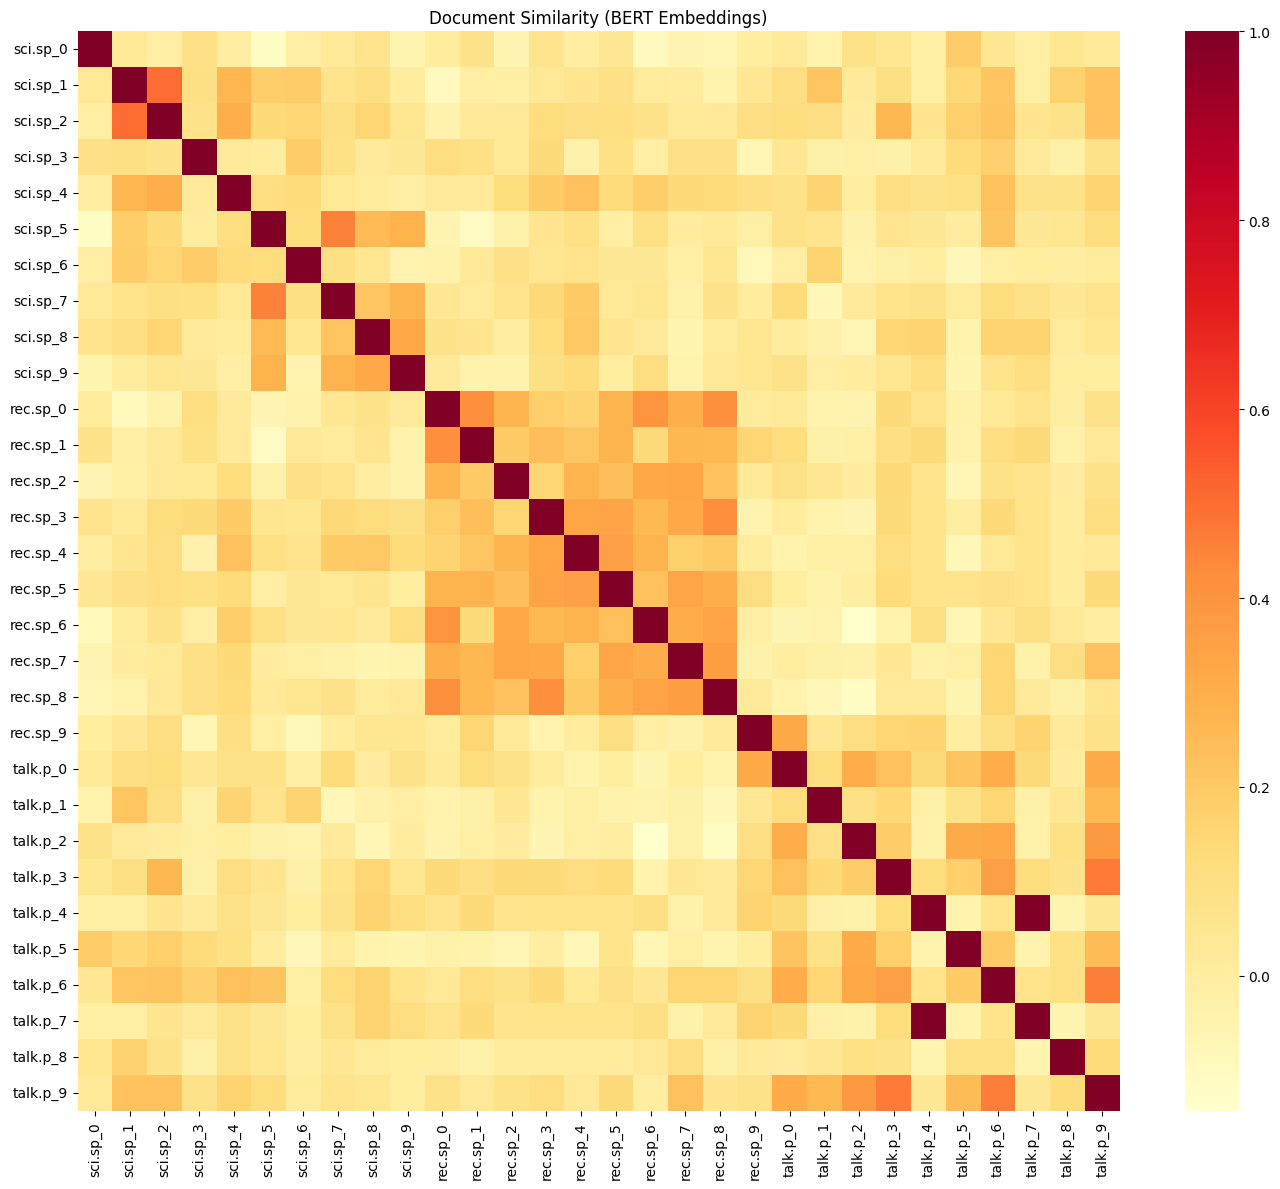

In [30]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. BERT shows very clear clustering here. Each category forms a distinct dark red block along the diagonal, meaning documents within the same category are much more similar to each other than to documents from other categories. TF-IDF clustering was decent but more scattered since it relies purely on keyword overlap rather than meaning.

2. BERT can consider two documents similar even if they share no exact words, because it understands semantic meaning. For example a sci.space document talking about "orbital mechanics" and another about "satellite trajectory" would score low on TF-IDF but high on BERT. The opposite can also happen where TF-IDF links documents that share jargon but are actually about different things.

3. BERT for classification without hesitation. The heatmap shows the three categories are almost perfectly separable, which means a classifier built on top of BERT embeddings would have very clean decision boundaries. TF-IDF is faster and lighter but misses too much semantic context for a reliable classifier.

### Exercise C.2: Semantic Search with BERT

In [31]:
def semantic_search(query, documents, model, top_k=5):
    query_embedding = model.encode([query])
    doc_embs = model.encode(documents)
    similarities = cosine_similarity(query_embedding, doc_embs)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]
    return [(idx, similarities[idx]) for idx in top_indices]

my_query = "space shuttle launch"  # write something matching one of your categories

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'space shuttle launch'

Top 5 most similar documents:

  Score: 0.4024
  Category: sci.space
  Text: From another space forum
    When workers at the Kennedy Space Center disassembled the STS-56
 solid rocket boosters they were surprised to find a pai...

  Score: 0.2344
  Category: sci.space
  Text: 
Lets hear it for Dan Goldin...now if he can only convince the rest of
our federal government that the space program is a worth while
investment!

I h...

  Score: 0.2042
  Category: sci.space
  Text: I am doing a political science paper on the funding of NASA and pork-barrel 
politics.  I would be interested in information about funding practices a...

  Score: 0.1997
  Category: sci.space
  Text: Hi all,

I really thought that by now I would have seen something
about this, but I haven't, so here goes:  Last night on
the evening news, the anchor...

  Score: 0.1956
  Category: sci.space
  Text: 

He's also the one who dubbed it the SR-71 - it was the RS-71 until LBJ
mippselled (sic

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. Relevance: Partially. The top result is clearly relevant, mentioning Kennedy Space Center and solid rocket boosters directly. The others are loosely related to space/NASA but not specifically about shuttle launches, and the last result about the SR-71 is barely relevant at all.

2. Category accuracy: Yes, all 5 results came from sci.space which is exactly the expected category, so BERT correctly identified the right domain even if some individual documents were not perfectly on topic.

3. Ambiguous query test: A query like "engine performance" could match both sci.space (rocket engines) and rec.sport (sports performance), and BERT would likely return a mix of both categories since the semantic meaning overlaps across domains.

---

## Part D: Embedding Visualization with t-SNE

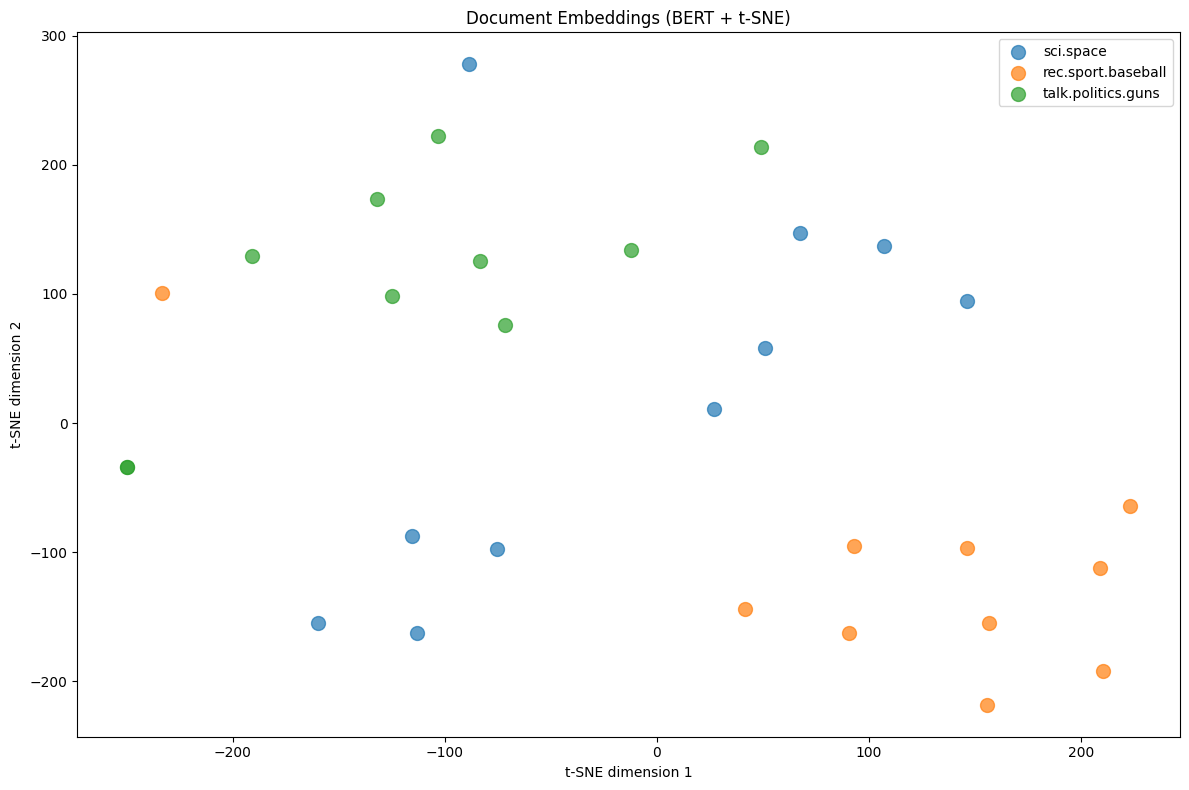

In [32]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = {'___': 'red', '___': 'blue', '___': 'green'}  # Update with your categories
# Actually use your categories:
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = [l == category for l in sampled_labels]
    plt.sacatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

1. Cluster quality: Partially. rec.sport.baseball and talk.politics.guns form fairly distinct clusters in the bottom-right and top-center areas respectively, but sci.space points are quite scattered across the plot, overlapping with both other categories.

2. Misplaced documents: Yes, there is one sci.space point sitting near the top at around (-100, 275) far from the other blue points, and a few green talk.politics.guns points mixed in with blue sci.space points in the middle region. This likely happens because those documents discuss general topics like government funding or policy which overlap semantically with political content.

3. Most similar categories: sci.space and talk.politics.guns appear most similar since their points overlap the most in the center of the plot. This actually makes some sense given that space funding and gun politics both involve government policy discussions, though it is a bit surprising compared to Part 1 where they seemed more distinct.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | Simple, fast, interpretable | Ignores word order and meaning, high dimensionality | Baseline text classification |
| TF-IDF | Highlights important words, filters noise | Still no semantic understanding, struggles with synonyms | Keyword-based search and retrieval |
| Word2Vec | Captures semantic relationships, compact vectors | Needs large corpus, no context per sentence | Domain-specific similarity tasks |
| GloVe | Broad vocabulary, good general semantics | Not domain-specific, static embeddings | General NLP tasks with limited data |
| BERT | Contextual, state-of-the-art semantic understanding | Slow, heavy, requires more compute | Classification, semantic search, QA |

### 2. Best Method for My Dataset

BERT performed best overall for sci.space, rec.sport.baseball, and talk.politics.guns. The heatmap showed near-perfect within-category clustering with all 5 semantic search results returning the correct sci.space category. Word2Vec gave strong results for space vocabulary like rocket and orbit but completely missed hockey and pixel due to vocabulary gaps. TF-IDF handled keyword matching well but struggled where categories shared political language, as seen in the sci.space and talk.politics.guns overlap in the t-SNE plot. BERT was the only method that consistently understood meaning rather than just matching words.

### 3. My Recommendation for a Real System

BERT with a lightweight classifier like logistic regression on top of the embeddings. The t-SNE plot shows the categories are semantically separable enough for BERT to handle well, and the semantic search results confirmed it retrieves the right category reliably. The compute cost is worth it given the semantic overlap between categories like space policy and gun politics that simpler methods would confuse.

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found